# MATH 616: Computational Linear Algebra
## Week 2 — SVD Applications, PCA, and Perturbation Theory

This notebook follows the Week 2 lecture and focuses on the computational ideas behind the pseudoinverse, numerical rank, PCA, and perturbation theory.

### Learning goals
- Compute the Moore–Penrose pseudoinverse from the SVD.
- Demonstrate noise amplification by small singular values.
- Use truncated SVD (TSVD) for stabilization.
- Interpret numerical rank from a singular-value spectrum.
- Implement PCA from the SVD of centered data.
- Analyze explained variance and reconstruction error.
- Visualize PCA directions and low-dimensional embeddings of handwritten digits.
- Verify Rayleigh-quotient and Weyl perturbation ideas numerically.

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)
rng = np.random.default_rng(616)

# Part I. The Moore–Penrose Pseudoinverse
If $A=U_r\Sigma_rV_r^T$ is the reduced SVD containing the nonzero singular values, then
$$A^+=V_r\Sigma_r^{-1}U_r^T=\sum_{i=1}^r\frac1{\sigma_i}v_iu_i^T.$$
For every matrix, $x=A^+b$ is the minimum-norm least-squares solution.

## 1. A pseudoinverse by hand
Use the lecture example
$$A=\begin{bmatrix}1&1\\1&1\\0&0\end{bmatrix},\qquad \operatorname{rank}(A)=1.$$

In [2]:
A = np.array([[1.,1.],[1.,1.],[0.,0.]])
U,s,Vt = np.linalg.svd(A, full_matrices=False)
print("Singular values:", s)
print("NumPy pseudoinverse:\n", np.linalg.pinv(A))

Singular values: [2. 0.]
NumPy pseudoinverse:
 [[0.25 0.25 0.  ]
 [0.25 0.25 0.  ]]


In [3]:
tol = max(A.shape)*np.finfo(float).eps*s[0]
keep = s > tol
Aplus = Vt[keep,:].T @ np.diag(1/s[keep]) @ U[:,keep].T
print("Tolerance =", tol)
print("Numerical rank =", keep.sum())
print("A^+ from SVD:\n", Aplus)

Tolerance = 1.3322676295501878e-15
Numerical rank = 1
A^+ from SVD:
 [[0.25 0.25 0.  ]
 [0.25 0.25 0.  ]]


Check that $A^+A$ is an orthogonal projector onto $\operatorname{range}(A^T)$.

In [4]:
P = Aplus @ A
print("A^+A =\n", P)
print("symmetric?", np.allclose(P,P.T))
print("idempotent?", np.allclose(P@P,P))

A^+A =
 [[0.5 0.5]
 [0.5 0.5]]
symmetric? True
idempotent? True


In [5]:
b = np.array([1.,1.,5.])
x = Aplus @ b
print("x = A^+b =", x)
print("Ax =", A@x)
print("residual =", b-A@x)

x = A^+b = [0.5 0.5]
Ax = [1. 1. 0.]
residual = [0. 0. 5.]


# Part II. Small Singular Values and Noise Amplification
The pseudoinverse contains $1/\sigma_i$. Therefore very small singular values can enormously amplify data errors.

## 2. Noise amplification

In [6]:
A_ill = np.diag([1.0,1e-6])
b_clean = np.array([1.0,0.0])
b_noisy = np.array([1.0,1e-3])
x_clean = np.linalg.pinv(A_ill)@b_clean
x_noisy = np.linalg.pinv(A_ill)@b_noisy
print("Clean solution:", x_clean)
print("Noisy solution:", x_noisy)
print("Condition number:", np.linalg.cond(A_ill))

Clean solution: [1. 0.]
Noisy solution: [   1. 1000.]
Condition number: 1000000.0


In [7]:
data_err=np.linalg.norm(b_noisy-b_clean)/np.linalg.norm(b_clean)
sol_err=np.linalg.norm(x_noisy-x_clean)/np.linalg.norm(x_clean)
print("Relative data perturbation =", data_err)
print("Relative solution perturbation =", sol_err)

Relative data perturbation = 0.001
Relative solution perturbation = 1000.0


## 3. Truncated-SVD rescue

In [8]:
def tsvd_solve(A,b,tol):
    U,s,Vt=np.linalg.svd(A,full_matrices=False)
    keep=s>tol
    return Vt[keep,:].T @ ((U[:,keep].T@b)/s[keep])

x_tsvd=tsvd_solve(A_ill,b_noisy,1e-4)
print("Pseudoinverse:", x_noisy)
print("TSVD:", x_tsvd)

Pseudoinverse: [   1. 1000.]
TSVD: [1. 0.]


# Part III. Numerical Rank
The lecture defines
$$\operatorname{rank}_\varepsilon(A)=\#\{i:\sigma_i>\varepsilon\}.$$

## 4. Reading numerical rank from a spectrum

epsilon-rank = 3


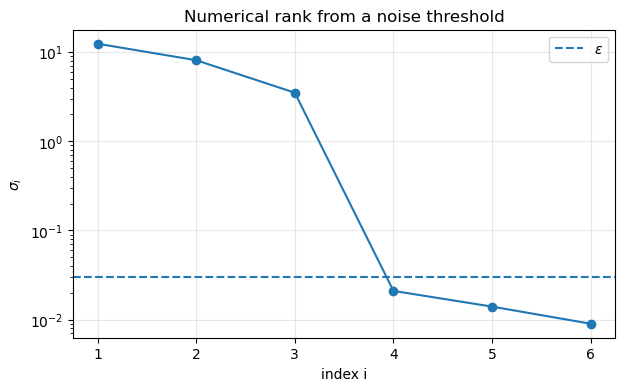

In [9]:
sigma=np.array([12.4,8.1,3.5,0.021,0.014,0.009])
eps=0.03
print("epsilon-rank =", np.sum(sigma>eps))
plt.figure(figsize=(7,4))
plt.semilogy(np.arange(1,len(sigma)+1),sigma,"o-")
plt.axhline(eps,ls="--",label=r"$\varepsilon$")
plt.xlabel("index i"); plt.ylabel(r"$\sigma_i$")
plt.title("Numerical rank from a noise threshold")
plt.legend(); plt.grid(True,alpha=.3); plt.show()

### Exercise
Repeat with the ambiguous spectrum $(12.4,3.1,0.9,0.24,0.06,0.017)$. Why is there no single obviously correct numerical rank?

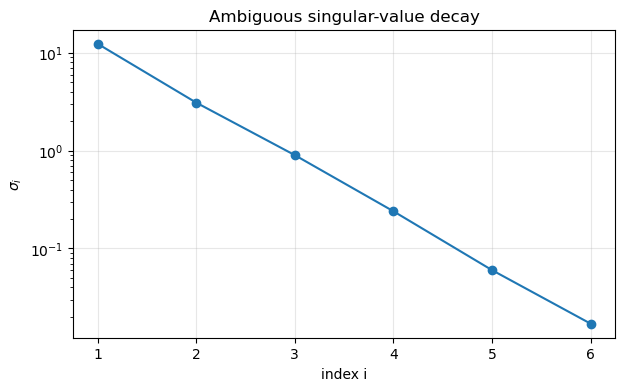

In [10]:
sigma2=np.array([12.4,3.1,0.9,0.24,0.06,0.017])
plt.figure(figsize=(7,4))
plt.semilogy(np.arange(1,len(sigma2)+1),sigma2,"o-")
plt.xlabel("index i"); plt.ylabel(r"$\sigma_i$")
plt.title("Ambiguous singular-value decay")
plt.grid(True,alpha=.3); plt.show()

# Part IV. PCA from the SVD
For data samples stored as rows of $X_{raw}$, center first: $X=X_{raw}-\bar x$. If
$$X=U\Sigma V^T,$$
then the columns of $V$ are principal directions, $\sigma_i^2/(m-1)$ is the variance along direction $v_i$, and the PCA scores are $XV_k=U_k\Sigma_k$.

**Do not form $X^TX$ explicitly.**

## 5. Warm-up: PCA on four points

In [11]:
X4=np.array([[2.,1.],[-2.,-1.],[1.,.5],[-1.,-.5]])
U4,s4,Vt4=np.linalg.svd(X4,full_matrices=False)
print("Singular values:",s4)
print("Principal directions:\n",Vt4)
print("Explained fractions:",s4**2/np.sum(s4**2))

Singular values: [3.53553 0.     ]
Principal directions:
 [[-0.89443 -0.44721]
 [ 0.44721 -0.89443]]
Explained fractions: [1. 0.]


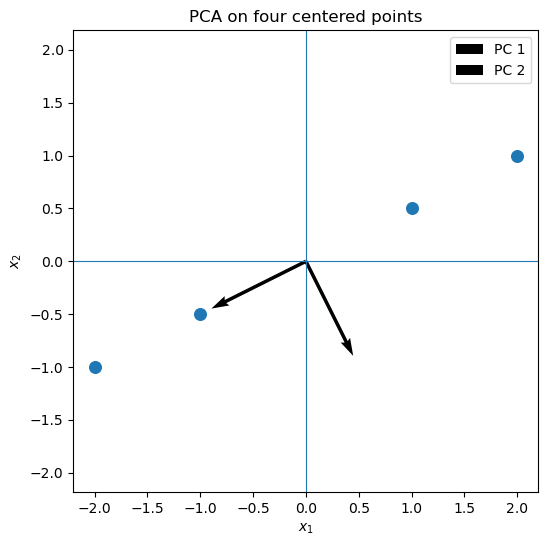

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(X4[:,0],X4[:,1],s=70)
for i in range(2):
    plt.quiver(0,0,Vt4[i,0],Vt4[i,1],angles="xy",scale_units="xy",scale=1,label=f"PC {i+1}")
plt.axhline(0,lw=.8); plt.axvline(0,lw=.8); plt.axis("equal")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("PCA on four centered points")
plt.legend(); plt.show()

In [13]:
X4p=X4.copy(); X4p[2]=[1.,.6]
X4pc=X4p-X4p.mean(axis=0)
_,s4p,_=np.linalg.svd(X4pc,full_matrices=False)
print("Perturbed singular values:",s4p)

Perturbed singular values: [3.54998 0.07182]


# Part V. — PCA on MNIST
MNIST contains 70,000 handwritten digit images of size $28\times28$, so each image is a vector in $\mathbb R^{784}$.

### Practical note
A full SVD of a $70{,}000\times784$ matrix can be expensive on a laptop. The default below uses 12,000 randomly selected images. Set `MAX_SAMPLES = None` to use the full dataset. The representative values in the lecture refer to the full centered MNIST dataset.

## 6. Load MNIST

In [14]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml("mnist_784",version=1,as_frame=False,parser="auto")
X_raw=mnist.data.astype(np.float64)/255.0
y=mnist.target.astype(int)
print("Full MNIST shape:",X_raw.shape)

Full MNIST shape: (70000, 784)


In [15]:
MAX_SAMPLES=12000  # set to None for all 70,000 images
if MAX_SAMPLES is not None and MAX_SAMPLES < len(X_raw):
    idx=rng.choice(len(X_raw),size=MAX_SAMPLES,replace=False)
    X_use=X_raw[idx]; y_use=y[idx]
else:
    X_use=X_raw; y_use=y
print("Working data shape:",X_use.shape)

Working data shape: (12000, 784)


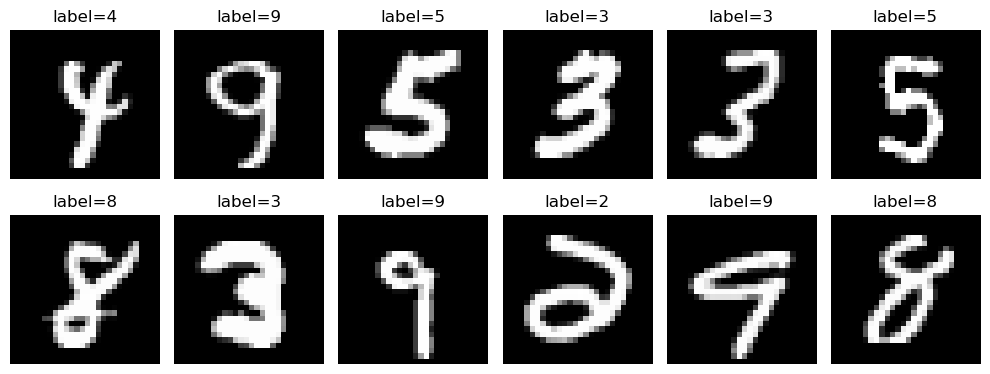

In [16]:
fig,axes=plt.subplots(2,6,figsize=(10,4))
for ax,img,label in zip(axes.ravel(),X_use[:12],y_use[:12]):
    ax.imshow(img.reshape(28,28),cmap="gray"); ax.set_title(f"label={label}"); ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Center the data

Centered shape: (12000, 784)
max abs column mean: 7.831309674818007e-15


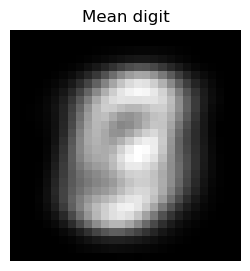

In [17]:
mean_digit=X_use.mean(axis=0)
X=X_use-mean_digit
print("Centered shape:",X.shape)
print("max abs column mean:",np.max(np.abs(X.mean(axis=0))))
plt.figure(figsize=(3,3)); plt.imshow(mean_digit.reshape(28,28),cmap="gray")
plt.title("Mean digit"); plt.axis("off"); plt.show()

## 8. Compute PCA directly from the SVD

In [18]:
U,s,Vt=np.linalg.svd(X,full_matrices=False)
print("U shape:",U.shape)
print("s shape:",s.shape)
print("Vt shape:",Vt.shape)

U shape: (12000, 784)
s shape: (784,)
Vt shape: (784, 784)


## 9. Singular-value spectrum

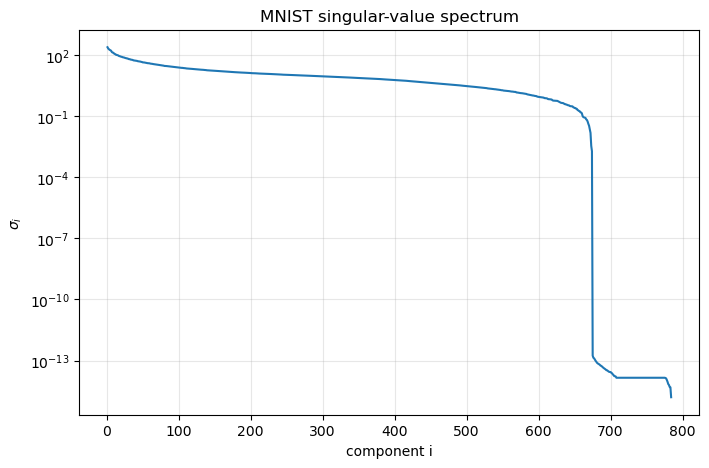

In [19]:
plt.figure(figsize=(8,5))
plt.semilogy(np.arange(1,len(s)+1),s)
plt.xlabel("component i"); plt.ylabel(r"$\sigma_i$")
plt.title("MNIST singular-value spectrum")
plt.grid(True,alpha=.3); plt.show()

**Discussion:** pixels near image borders are almost always zero. Where does this show up? It appears in the tail as directions with extremely small or zero variance.

## 10. Explained variance

In [20]:
explained=s**2/np.sum(s**2)
cum=np.cumsum(explained)
k90=np.searchsorted(cum,.90)+1
k95=np.searchsorted(cum,.95)+1
print("k for 90%:",k90)
print("k for 95%:",k95)
for k in [2,10,50,100,150]:
    if k<=len(cum): print(f"rho_{k} = {cum[k-1]:.4f}")

k for 90%: 86
k for 95%: 152
rho_2 = 0.1686
rho_10 = 0.4908
rho_50 = 0.8271
rho_100 = 0.9161
rho_150 = 0.9495


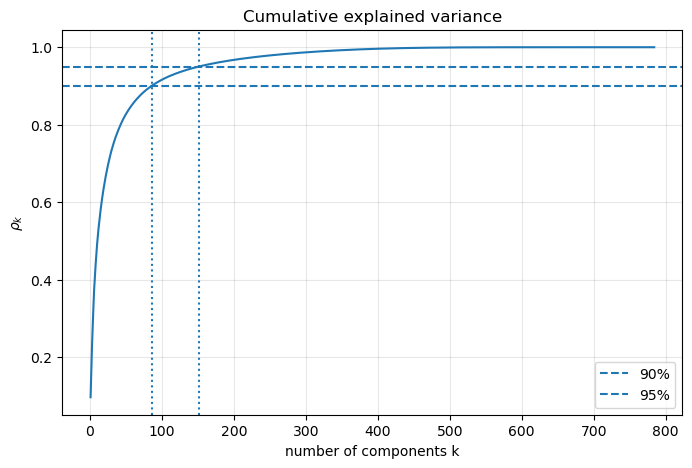

In [21]:
plt.figure(figsize=(8,5))
plt.plot(np.arange(1,len(cum)+1),cum)
plt.axhline(.90,ls="--",label="90%"); plt.axhline(.95,ls="--",label="95%")
plt.axvline(k90,ls=":"); plt.axvline(k95,ls=":")
plt.xlabel("number of components k"); plt.ylabel(r"$\rho_k$")
plt.title("Cumulative explained variance")
plt.legend(); plt.grid(True,alpha=.3); plt.show()

Representative full-MNIST values from the lecture are approximately $\rho_2=0.17$, $\rho_{10}=0.49$, $\rho_{50}=0.82$, $\rho_{100}=0.91$, and $\rho_{150}=0.95$. Subset results will vary.

## 11. Visualize the top 16 principal directions (“eigendigits”)

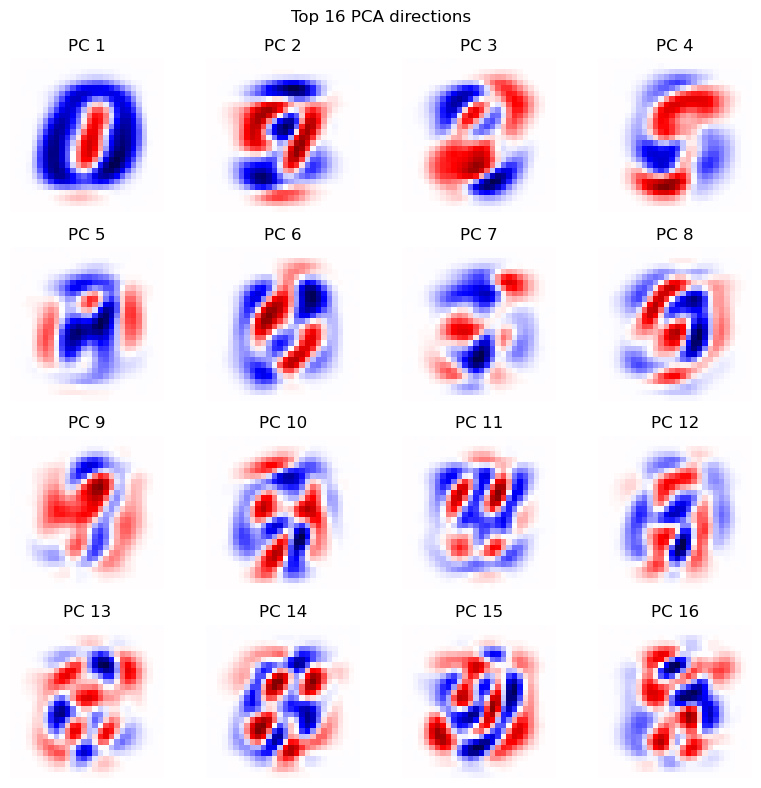

In [22]:
fig,axes=plt.subplots(4,4,figsize=(8,8))
for i,ax in enumerate(axes.ravel()):
    vmax=np.max(np.abs(Vt[i]))
    ax.imshow(Vt[i].reshape(28,28),cmap="seismic",vmin=-vmax,vmax=vmax)
    ax.set_title(f"PC {i+1}"); ax.axis("off")
plt.suptitle("Top 16 PCA directions")
plt.tight_layout(); plt.show()

## 12. Reconstruct sample digits at k = 5, 20, 50, 150

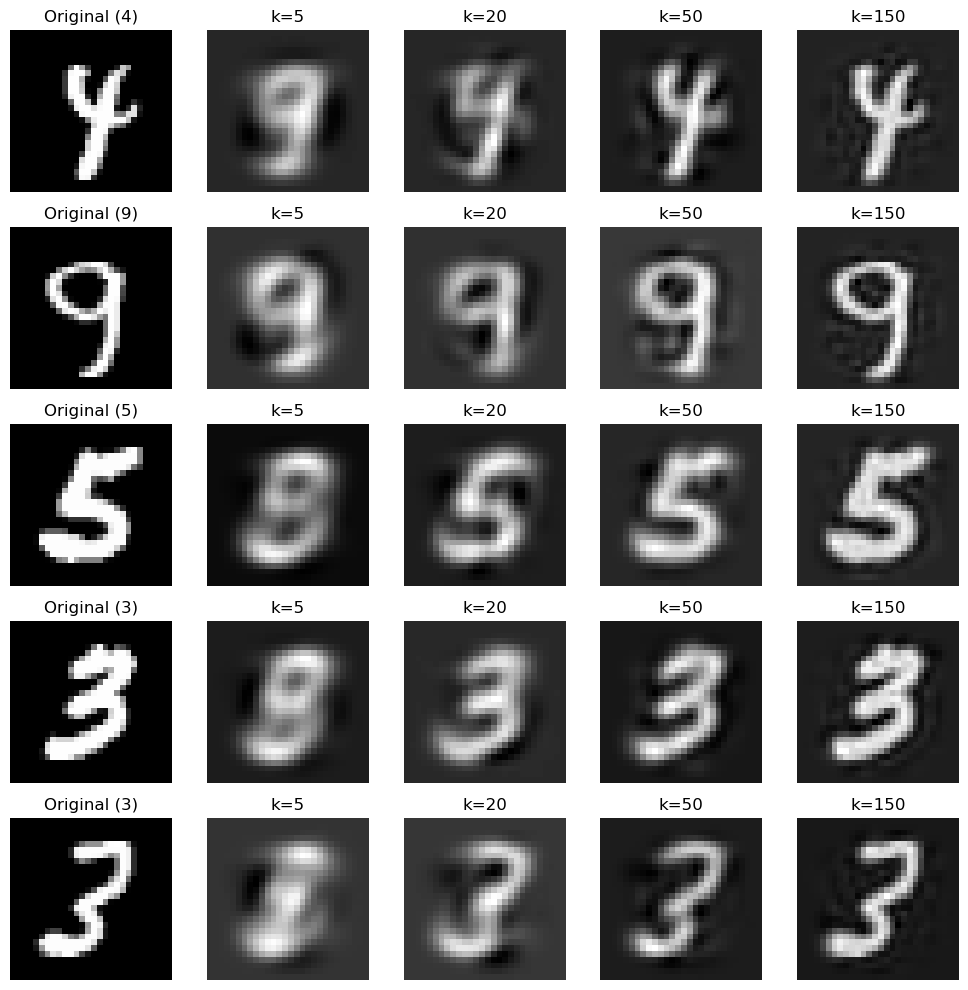

In [23]:
def pca_reconstruct(x,mean,Vt,k):
    z=(x-mean)@Vt[:k].T
    return mean+z@Vt[:k]

ids=[0,1,2,3,4]; ks=[5,20,50,150]
fig,axes=plt.subplots(len(ids),len(ks)+1,figsize=(10,2*len(ids)))
for r,idx in enumerate(ids):
    axes[r,0].imshow(X_use[idx].reshape(28,28),cmap="gray")
    axes[r,0].set_title(f"Original ({y_use[idx]})"); axes[r,0].axis("off")
    for c0,k in enumerate(ks,1):
        xr=pca_reconstruct(X_use[idx],mean_digit,Vt,k)
        axes[r,c0].imshow(xr.reshape(28,28),cmap="gray")
        axes[r,c0].set_title(f"k={k}"); axes[r,c0].axis("off")
plt.tight_layout(); plt.show()

## 13. Project onto the first two principal components

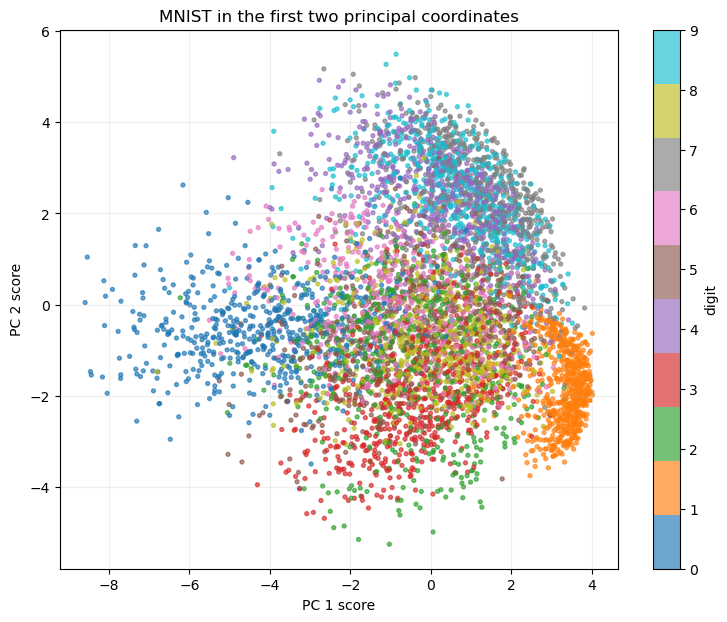

In [24]:
scores2=X@Vt[:2].T
plot_n=min(6000,len(scores2))
plot_idx=rng.choice(len(scores2),size=plot_n,replace=False)
plt.figure(figsize=(9,7))
sc=plt.scatter(scores2[plot_idx,0],scores2[plot_idx,1],c=y_use[plot_idx],s=8,cmap="tab10",alpha=.65)
plt.xlabel("PC 1 score"); plt.ylabel("PC 2 score")
plt.title("MNIST in the first two principal coordinates")
plt.colorbar(sc,ticks=range(10),label="digit")
plt.grid(True,alpha=.2); plt.show()

Two PCs retain only a modest fraction of total variance, so visible structure is expected without complete class separation.

## 14. Verify against scikit-learn PCA

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=min(150,X_use.shape[1]),svd_solver="full")
pca.fit(X_use)
print("First 10 singular values")
print("NumPy :",s[:10])
print("sklearn:",pca.singular_values_[:10])
print("\nFirst 10 explained variance ratios")
print("NumPy :",explained[:10])
print("sklearn:",pca.explained_variance_ratio_[:10])

Signs of principal vectors may differ between implementations; singular vectors are only determined up to sign.

# Part VI. Rayleigh Quotients and Variational Principles
For symmetric $S$,
$$R(x)=\frac{x^TSx}{x^Tx}.$$

## 15. Rayleigh quotient example

In [25]:
S=np.array([[3.,1.],[1.,3.]])
evals,Q=np.linalg.eigh(S); idx=np.argsort(evals)[::-1]; evals=evals[idx]; Q=Q[:,idx]
def RQ(S,x):
    x=np.asarray(x,float); return (x@S@x)/(x@x)
q1,q2=Q[:,0],Q[:,1]
for name,x in {"q1":q1,"q2":q2,"e1":np.array([1.,0.]),"(2,1)":np.array([2.,1.])}.items():
    print(name,RQ(S,x))

q1 4.0
q2 2.0
e1 3.0
(2,1) 3.8


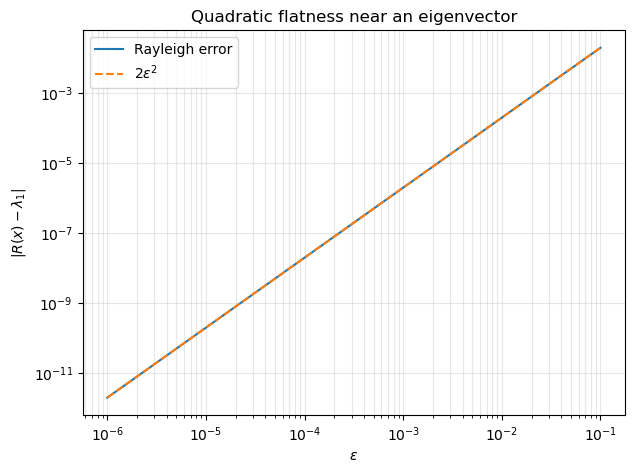

In [26]:
epsv=np.logspace(-6,-1,40)
err=np.array([abs(RQ(S,q1+e*q2)-evals[0]) for e in epsv])
plt.figure(figsize=(7,5))
plt.loglog(epsv,err,label="Rayleigh error")
plt.loglog(epsv,2*epsv**2,"--",label=r"$2\varepsilon^2$")
plt.xlabel(r"$\varepsilon$"); plt.ylabel(r"$|R(x)-\lambda_1|$")
plt.title("Quadratic flatness near an eigenvector")
plt.legend(); plt.grid(True,which="both",alpha=.3); plt.show()

# Part VII. Weyl Perturbation Bounds
For symmetric $S$,
$$|\lambda_k(S+E)-\lambda_k(S)|\le \|E\|_2,$$
and for general matrices,
$$|\sigma_k(A+E)-\sigma_k(A)|\le \|E\|_2.$$

## 16. Weyl's eigenvalue bound

In [ ]:
S=np.diag([5.,3.,1.])
E=np.array([[0.,.1,0.],[.1,0.,0.],[0.,0.,0.]])
lamS=np.linalg.eigvalsh(S)[::-1]; lamSE=np.linalg.eigvalsh(S+E)[::-1]
En=np.linalg.norm(E,2); shifts=np.abs(lamSE-lamS)
print("lambda(S)   =",lamS)
print("lambda(S+E) =",lamSE)
print("||E||_2 =",En)
print("shifts =",shifts)
print("Weyl satisfied?",np.all(shifts<=En+1e-14))

## 17. Weyl's singular-value bound

In [ ]:
A=rng.standard_normal((8,5)); E=.03*rng.standard_normal((8,5))
sA=np.linalg.svd(A,compute_uv=False); sAE=np.linalg.svd(A+E,compute_uv=False)
En=np.linalg.norm(E,2); d=np.abs(sAE-sA)
print("||E||_2 =",En)
print("max shift =",d.max())
print("Weyl satisfied?",np.all(d<=En+1e-14))

# Part VIII. Why Low-Rank Structure Survives Noise
If $\widetilde A=A+E$ and $A$ has rank $k$, then a strong spectral gap survives whenever $\sigma_k(A)\gg\|E\|_2$.

## 18. Synthetic low-rank signal plus noise

In [ ]:
m,n,r=80,60,5
Q1,_=np.linalg.qr(rng.standard_normal((m,r))); Q2,_=np.linalg.qr(rng.standard_normal((n,r)))
ss=np.array([10.,7.,5.,3.,2.])
As=Q1@np.diag(ss)@Q2.T
noise=rng.standard_normal((m,n)); noise=noise/np.linalg.norm(noise,2)*.25
Aobs=As+noise; sobs=np.linalg.svd(Aobs,compute_uv=False); en=np.linalg.norm(noise,2)
print("||E||_2 =",en)
print("Leading observed singular values:",sobs[:10])
plt.figure(figsize=(8,5))
plt.semilogy(np.arange(1,len(sobs)+1),sobs,"o-",ms=3,label=r"$A+E$")
plt.axhline(en,ls="--",label=r"$\|E\|_2$")
plt.xlabel("index i"); plt.ylabel(r"$\sigma_i$")
plt.title("Low-rank signal plus noise")
plt.legend(); plt.grid(True,alpha=.3); plt.show()

# Optional connections
### LoRA
Low-Rank Adaptation uses $W'=W+BA$ with $r\ll d$, so the update has rank at most $r$. Eckart–Young explains why this is effective when the desired update has rapidly decaying singular values.

### POD
In scientific computing, PCA of a centered snapshot matrix is called **Proper Orthogonal Decomposition (POD)**. The right singular vectors are spatial modes and $\sigma_i^2$ measures modal energy.

# Exercises
1. **Pseudoinverse identities:** verify $AA^+A=A$, $A^+AA^+=A^+$, and the symmetry of $AA^+$ and $A^+A$.
2. **Regularization:** repeat the noise-amplification experiment with small singular values $10^{-3}$, $10^{-8}$, and $10^{-10}$.
3. **Numerical rank:** add controlled noise to an exactly rank-3 matrix and compare the singular-value tail with the noise norm.
4. **PCA reconstruction:** verify $\|X-X_k\|_F^2/\|X\|_F^2=1-\rho_k$.
5. **Alternative PCA views:** scatter components $(v_2,v_3)$ or $(v_3,v_4)$ and compare class structure.
6. **Weyl experiment:** generate many perturbations with the same spectral norm and measure how close the observed shift comes to the worst-case bound.

# Summary
- The pseudoinverse extends the role of an inverse to rectangular and rank-deficient matrices.
- Small singular values cause instability by amplifying noise.
- TSVD trades resolution for stability.
- Numerical rank depends on singular values relative to an error scale.
- PCA is the SVD of centered data.
- Explained variance and reconstruction error are governed by the same singular-value tail.
- Rayleigh quotients and Courant–Fischer provide variational characterizations.
- Weyl's inequality guarantees that singular values cannot move more than the perturbation norm.
- Strong low-rank structure therefore survives sufficiently small noise.